In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn import decomposition
from sklearn.manifold import MDS
from sklearn.preprocessing import FunctionTransformer
from scipy.spatial import cKDTree

import h3
from shapely import Polygon

import umap
from sklearn.cluster import KMeans 

import rasterio
import rioxarray
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.features import rasterize, shapes
from rasterio.transform import from_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling

temp_path = 'C:/Users/vladk/NC_DATA/lect/'

SEED = 171225

C:\Users\v.kozlovskiy\AppData\Roaming\Python\Python39\site-packages\umap\distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
C:\Users\v.kozlovskiy\AppData\Roaming\Python\Python39\site-packages\umap\distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
C:\Users\v.kozlovskiy\AppData\Roaming\Python\Python39\site-pac

# Bathymetry cut-off to area of interest

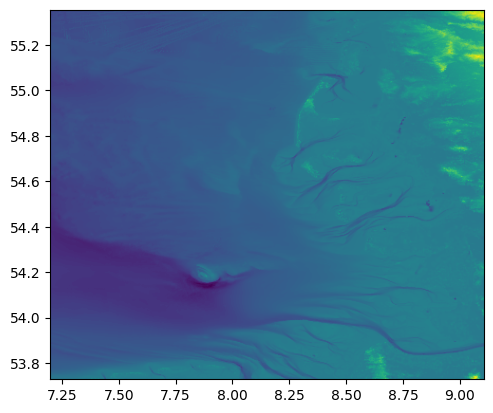

<Axes: >

In [2]:
# here i used geotiff - not ncdf
geotif_depth = '01_support_data/gebco_2025_n55.3546_s53.7286_w7.2015_e9.1022.tif'
src = rasterio.open(geotif_depth)
show(src)

In [3]:
area = gpd.read_file('01_support_data/area_ns.geojson')
print(area)

# crop bathymetry to area (additional for full compliance)
with rasterio.open(geotif_depth) as src:
    out_image, out_transform = mask(src, area.geometry, crop=True)
    
    # Save cropped raster
    out_meta = src.meta
    out_meta.update({"transform": out_transform, "height": out_image.shape[1], "width": out_image.shape[2]})
    
    with rasterio.open("01_support_data/area_depth_croped.tif", "w", **out_meta) as dest:
        dest.write(out_image)

   id                                           geometry
0   1  MULTIPOLYGON (((7.25268 55.18374, 8.25455 55.1...


# Benthic data which i took from internet (Pangea database)

this dataset:
https://doi.pangaea.de/10.1594/PANGAEA.870461  

below some table manipulations in pandas to obtain data form which i want use to ml, analytics and mapping 


In [4]:
data = pd.read_csv('01_support_data/HE335_species_composition.tab', sep='\t', header=[405])
data.head()

,Event,Sample label,Date/Time,Latitude,Longitude,Bathy depth [m],Depth sed [m],A. filiformis [#],A. rubens [#],E. cordatum [#],...,Tubulanus [#],Oligochaeta [#],Polycladida [#],P. muelleri [#],P. pallida [#],A. scabra [#],G. vulgaris [#],A. petiolatus [#],N. gracile [#],B. lanceolatum [#]
0,HE335/001-1,HE335-1-1,2010-09-09T08:17,54.1683,8.1702,21.2,0.054,0,0,0,...,0,0,0,10,0,0,0,0,0,0
1,HE335/001-2,HE335-1-2,2010-09-09T08:21,54.1690,8.1705,21.2,0.162,0,0,0,...,0,7,0,10,0,0,0,0,0,0
2,HE335/001-3,HE335-1-3,2010-09-09T08:24,54.1695,8.1708,21.2,0.176,2,0,0,...,0,0,0,4,0,0,0,0,0,0
3,HE335/032-1,HE335-2-1,2010-09-10T05:20,54.1673,8.0003,22.8,0.065,0,0,1,...,0,0,0,3,55,0,0,0,0,0
4,HE335/032-2,HE335-2-2,2010-09-10T05:25,54.1675,7.9978,22.4,0.130,3,0,1,...,0,0,0,5,1,0,2,0,0,0


In [5]:
data.columns

Index(['Event', 'Sample label', 'Date/Time', 'Latitude', 'Longitude',
       'Bathy depth [m]', 'Depth sed [m]', 'A. filiformis [#]',
       'A. rubens [#]', 'E. cordatum [#]',
       ...
       'Tubulanus [#]', 'Oligochaeta [#]', 'Polycladida [#]',
       'P. muelleri [#]', 'P. pallida [#]', 'A. scabra [#]', 'G. vulgaris [#]',
       'A. petiolatus [#]', 'N. gracile [#]', 'B. lanceolatum [#]'],
      dtype='object', length=146)

In [6]:
data['station'] = data['Sample label'].apply(lambda x: x[:-2])
data['Date/Time'] = pd.to_datetime(data['Date/Time'])
agg_dict = {'Latitude':'mean', 'Longitude': 'mean', 'Bathy depth [m]': 'mean', 'Date/Time': 'max'}

In [7]:
g1 = data.drop(['Event', 'Sample label', 'Date/Time', 'Latitude', 'Longitude',
       'Bathy depth [m]', 'Depth sed [m]'], axis=1).groupby('station').agg(['sum']).reset_index()
g1.columns = data.drop(['Event', 'Sample label', 'Date/Time', 'Latitude', 'Longitude',
       'Bathy depth [m]', 'Depth sed [m]', 'station'], axis=1).columns.insert(0,'station')
g1 = g1.set_index('station')
g1 = g1 / 0.06
g1.head()

,A. filiformis [#],A. rubens [#],E. cordatum [#],E. pusillus [#],O. ophiura [#],Holothuroidea [#],A. nitida [#],A. tornatilis [#],A. papillosa [#],A. pygmaea [#],...,Tubulanus [#],Oligochaeta [#],Polycladida [#],P. muelleri [#],P. pallida [#],A. scabra [#],G. vulgaris [#],A. petiolatus [#],N. gracile [#],B. lanceolatum [#]
station,,,,,,,,,,,,,,,,,,,,,
HE335-1,33.333333,0.0,0.000000,0.0,66.666667,0.000000,50.000000,0.000000,0.0,0.0,...,0.000000,116.666667,0.0,400.000000,0.000000,0.0,0.0,0.0,0.0,0.0
HE335-100,0.000000,0.0,16.666667,0.0,0.000000,0.000000,16.666667,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,83.333333,0.000000,0.0,0.0,0.0,0.0,0.0
HE335-101,0.000000,0.0,16.666667,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
HE335-11,0.000000,0.0,50.000000,0.0,0.000000,0.000000,83.333333,0.000000,0.0,0.0,...,66.666667,0.000000,0.0,3750.000000,0.000000,0.0,0.0,0.0,0.0,0.0
HE335-12,366.666667,0.0,33.333333,0.0,0.000000,16.666667,66.666667,16.666667,0.0,0.0,...,50.000000,0.000000,0.0,4250.000000,16.666667,0.0,0.0,0.0,0.0,0.0


In [8]:
# way to definite dominants it will be useful in some demonstration but it is not good way for real analysis
def domspec(data):
    dom_list = []
    for i in g1.iterrows():
    #print(np.array(i[1]).argmax())
        dom_list.append(g1.columns.tolist()[np.array(i[1]).argmax()][:-4])
    return dom_list
dom_labels = domspec(g1)
np.unique(dom_labels)

array(['A. filiformis', 'A. paucibranchiata', 'E. directus',
       'L. conchilega', 'M. johnstoni', 'O. limacina', 'P. muelleri',
       'P. pallida', 'P. remota', 'S. armiger', 'S. bombyx',
       'S. inflatum', 'Spio spp.'], dtype='<U18')

In [9]:
g2 = data[['Latitude', 'Longitude', 'Bathy depth [m]', 'Date/Time', 'station']].groupby('station').agg(agg_dict)
g3 = g2.join(g1)
g3 = g3.reset_index()
gdf = gpd.GeoDataFrame(
    g3, geometry=gpd.points_from_xy(g3.Longitude, g3.Latitude), crs="EPSG:4326"
)

In [11]:
# add few cols with common information
gdf['dominants'] = dom_labels
gdf['number_of_species'] = list(g1.map(lambda x: 1 if x > 0 else 0).sum(axis=1))
gdf['total_abundance'] = list(g1.sum(axis=1))
gdf.head()

,station,Latitude,Longitude,Bathy depth [m],Date/Time,A. filiformis [#],A. rubens [#],E. cordatum [#],E. pusillus [#],O. ophiura [#],...,P. pallida [#],A. scabra [#],G. vulgaris [#],A. petiolatus [#],N. gracile [#],B. lanceolatum [#],geometry,dominants,number_of_species,total_abundance
0,HE335-1,54.168933,8.170500,21.200000,2010-09-09 08:24:00,33.333333,0.0,0.000000,0.0,66.666667,...,0.000000,0.0,0.0,0.0,0.0,0.0,POINT (8.17050 54.16893),S. inflatum,22,3616.666667
1,HE335-100,55.083433,8.000000,18.066667,2010-09-09 17:42:00,0.000000,0.0,16.666667,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,POINT (8.00000 55.08343),E. directus,25,4483.333333
2,HE335-101,55.083433,8.165000,16.133333,2010-09-09 16:56:00,0.000000,0.0,16.666667,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,POINT (8.16500 55.08343),S. bombyx,21,6816.666667
3,HE335-11,54.248267,7.335333,39.600000,2010-09-11 20:38:00,0.000000,0.0,50.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,POINT (7.33533 54.24827),P. muelleri,33,5666.666667
4,HE335-12,54.250000,7.504100,42.033333,2010-09-11 02:17:00,366.666667,0.0,33.333333,0.0,0.000000,...,16.666667,0.0,0.0,0.0,0.0,0.0,POINT (7.50410 54.25000),P. muelleri,31,6400.000000


In [12]:
# transformation of data - here i use sqare transform which often applied in similar cases
col_save = g1.columns
labels = g1.index
sqrtran = FunctionTransformer(np.sqrt)
transformed = sqrtran.fit_transform(g1)
transformed.columns = col_save
transformed.head()

,A. filiformis [#],A. rubens [#],E. cordatum [#],E. pusillus [#],O. ophiura [#],Holothuroidea [#],A. nitida [#],A. tornatilis [#],A. papillosa [#],A. pygmaea [#],...,Tubulanus [#],Oligochaeta [#],Polycladida [#],P. muelleri [#],P. pallida [#],A. scabra [#],G. vulgaris [#],A. petiolatus [#],N. gracile [#],B. lanceolatum [#]
station,,,,,,,,,,,,,,,,,,,,,
HE335-1,5.773503,0.0,0.000000,0.0,8.164966,0.000000,7.071068,0.000000,0.0,0.0,...,0.000000,10.801234,0.0,20.000000,0.000000,0.0,0.0,0.0,0.0,0.0
HE335-100,0.000000,0.0,4.082483,0.0,0.000000,0.000000,4.082483,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,9.128709,0.000000,0.0,0.0,0.0,0.0,0.0
HE335-101,0.000000,0.0,4.082483,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
HE335-11,0.000000,0.0,7.071068,0.0,0.000000,0.000000,9.128709,0.000000,0.0,0.0,...,8.164966,0.000000,0.0,61.237244,0.000000,0.0,0.0,0.0,0.0,0.0
HE335-12,19.148542,0.0,5.773503,0.0,0.000000,4.082483,8.164966,4.082483,0.0,0.0,...,7.071068,0.000000,0.0,65.192024,4.082483,0.0,0.0,0.0,0.0,0.0


In [13]:
# dimension reduction using UMAP
reducer = umap.UMAP(random_state=SEED)
embedding = reducer.fit_transform(transformed)
embedding.shape
ordination_umap = pd.DataFrame(embedding, columns=['X', 'Y'])
ordination_umap.head()

,X,Y
0,6.975221,6.565768
1,8.157071,5.053275
2,7.699515,4.784207
3,5.451074,7.918703
4,5.291736,7.911386


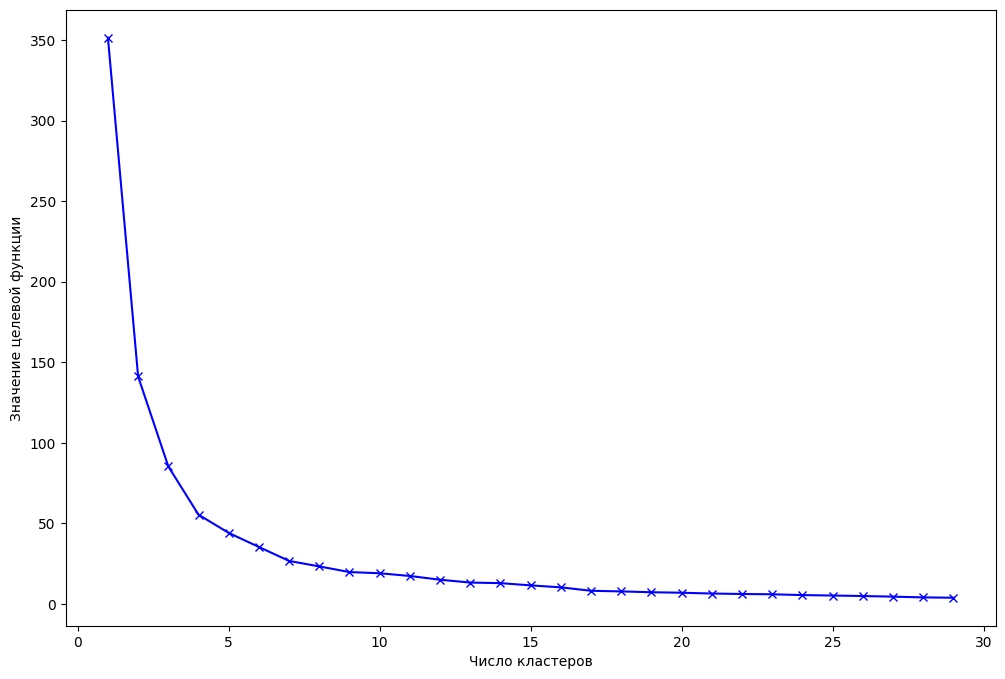

distortion: [351.4898986816406, 141.1429901123047, 85.28802490234375, 55.34745788574219, 44.01527786254883, 35.281410217285156, 26.604961395263672, 23.212493896484375, 19.700258255004883, 18.962644577026367, 17.272153854370117, 14.937313079833984, 13.184176445007324, 12.821775436401367, 11.439916610717773, 10.210733413696289, 8.085305213928223, 7.685944557189941, 7.176762580871582, 6.862831115722656, 6.371095657348633, 6.088939189910889, 5.90529203414917, 5.403739929199219, 5.1286516189575195, 4.825021743774414, 4.4399094581604, 3.9663286209106445, 3.7696666717529297]
change_distortion: [2.4903107012396934, 1.6548980970530838, 1.5409564984612314, 1.2574601496003628, 1.2475487116720962, 1.3261214588180572, 1.1461483420914587, 1.1782837359803242, 1.0388982493967192, 1.0978737647261363, 1.1563092881602828, 1.1329727831039875, 1.0282644950696211, 1.1207927358831413, 1.1203814796861413, 1.2628754442202972, 1.0519598669710273, 1.0709487001389033, 1.0457437258553126, 1.077182243811838, 1.0463

In [14]:
# here approach to select optimal number of clusters (k-means) automatically basing on elbow method 
def number_of_clusters(data):

# k-means for all data   
    distortion = []
    K = range(1, 30)
    for k in K:
        model = KMeans(n_clusters=k, random_state=SEED)
        model.fit(data)
        distortion.append(model.inertia_) 
        
   # show plot
    plt.figure(figsize=(12, 8))
    plt.plot(K, distortion, 'bx-')
    plt.xlabel('Число кластеров')
    plt.ylabel('Значение целевой функции')
    plt.show() 
        
    print('distortion:', distortion)
    cnange_distortion = []
    for i in range(1, len(distortion)):
        cnange_distortion.append(distortion[i-1] / distortion[i])
    print('change_distortion:', cnange_distortion)
    print('quantile 0.8:', np.quantile(cnange_distortion, 0.80))
    
    stop_search=0
    for x in range(len(cnange_distortion)):
        if stop_search == 0:
            if cnange_distortion[x] < np.quantile(cnange_distortion, 0.85):
                needable_K = x
                stop_search=1
            
    number_of_clusters = K[needable_K]
    print()
    print('number_of_cluster:', number_of_clusters)
          
    model = KMeans(n_clusters=number_of_clusters, random_state=SEED)
    model.fit(data)

    klusters = model.labels_      
               
    return klusters
    
clusters = number_of_clusters(ordination_umap)

In [15]:
# comparison of defined clusters and community - community named but mostly occured dominant species in cluster (using mode)
comms = {}
gdf['cluster'] = clusters
print(np.unique(clusters))
for i in np.unique(clusters):
    tmp = gdf.loc[gdf['cluster'] == i]
    res = tmp['dominants'].mode()[0]
    comms[i] = res
    print(res)
print(comms)
gdf['community'] = gdf['cluster'].map(comms)
gdf.head()

[0 1 2 3]
S. armiger
E. directus
P. muelleri
S. bombyx
{0: 'S. armiger', 1: 'E. directus', 2: 'P. muelleri', 3: 'S. bombyx'}


,station,Latitude,Longitude,Bathy depth [m],Date/Time,A. filiformis [#],A. rubens [#],E. cordatum [#],E. pusillus [#],O. ophiura [#],...,G. vulgaris [#],A. petiolatus [#],N. gracile [#],B. lanceolatum [#],geometry,dominants,number_of_species,total_abundance,cluster,community
0,HE335-1,54.168933,8.170500,21.200000,2010-09-09 08:24:00,33.333333,0.0,0.000000,0.0,66.666667,...,0.0,0.0,0.0,0.0,POINT (8.17050 54.16893),S. inflatum,22,3616.666667,0,S. armiger
1,HE335-100,55.083433,8.000000,18.066667,2010-09-09 17:42:00,0.000000,0.0,16.666667,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (8.00000 55.08343),E. directus,25,4483.333333,3,S. bombyx
2,HE335-101,55.083433,8.165000,16.133333,2010-09-09 16:56:00,0.000000,0.0,16.666667,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (8.16500 55.08343),S. bombyx,21,6816.666667,3,S. bombyx
3,HE335-11,54.248267,7.335333,39.600000,2010-09-11 20:38:00,0.000000,0.0,50.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (7.33533 54.24827),P. muelleri,33,5666.666667,2,P. muelleri
4,HE335-12,54.250000,7.504100,42.033333,2010-09-11 02:17:00,366.666667,0.0,33.333333,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (7.50410 54.25000),P. muelleri,31,6400.000000,2,P. muelleri


In [16]:
comms

{0: 'S. armiger', 1: 'E. directus', 2: 'P. muelleri', 3: 'S. bombyx'}

In [17]:
dict_groups_colors = {0 :'lime',
                      1 : 'magenta',
                      2 : 'cyan',
                      3 : 'red',
                      4: 'green',
                      5: 'blue'}

dict_markers_from_colors = {'navy':'v',
                      'magenta': 'o',
                      'lime': 'o',
                      'red': 'D',
                      'cyan':'s',
                      'green': 'p',
                      'blue': '*'}

ordination_umap['community'] = gdf['community']
ordination_umap['station'] = gdf['station']
ordination_umap['cluster'] = gdf['cluster']
ordination_umap['color'] = ordination_umap['cluster'].map(dict_groups_colors)
ordination_umap['marker'] = ordination_umap['color'].map(dict_markers_from_colors)
ordination_umap

,X,Y,community,station,cluster,color,marker
0,6.975221,6.565768,S. armiger,HE335-1,0,lime,o
1,8.157071,5.053275,S. bombyx,HE335-100,3,red,D
2,7.699515,4.784207,S. bombyx,HE335-101,3,red,D
3,5.451074,7.918703,P. muelleri,HE335-11,2,cyan,s
4,5.291736,7.911386,P. muelleri,HE335-12,2,cyan,s
...,...,...,...,...,...,...,...
78,6.159545,5.485374,S. armiger,HE335-S5,0,lime,o
79,8.276968,4.947581,S. bombyx,HE335-S6,3,red,D
80,9.211635,5.375137,S. bombyx,HE335-S7,3,red,D
81,8.016346,4.380183,S. bombyx,HE335-S8,3,red,D


In [18]:
ordination_umap.community.value_counts()

community
S. armiger     26
E. directus    21
P. muelleri    20
S. bombyx      16
Name: count, dtype: int64

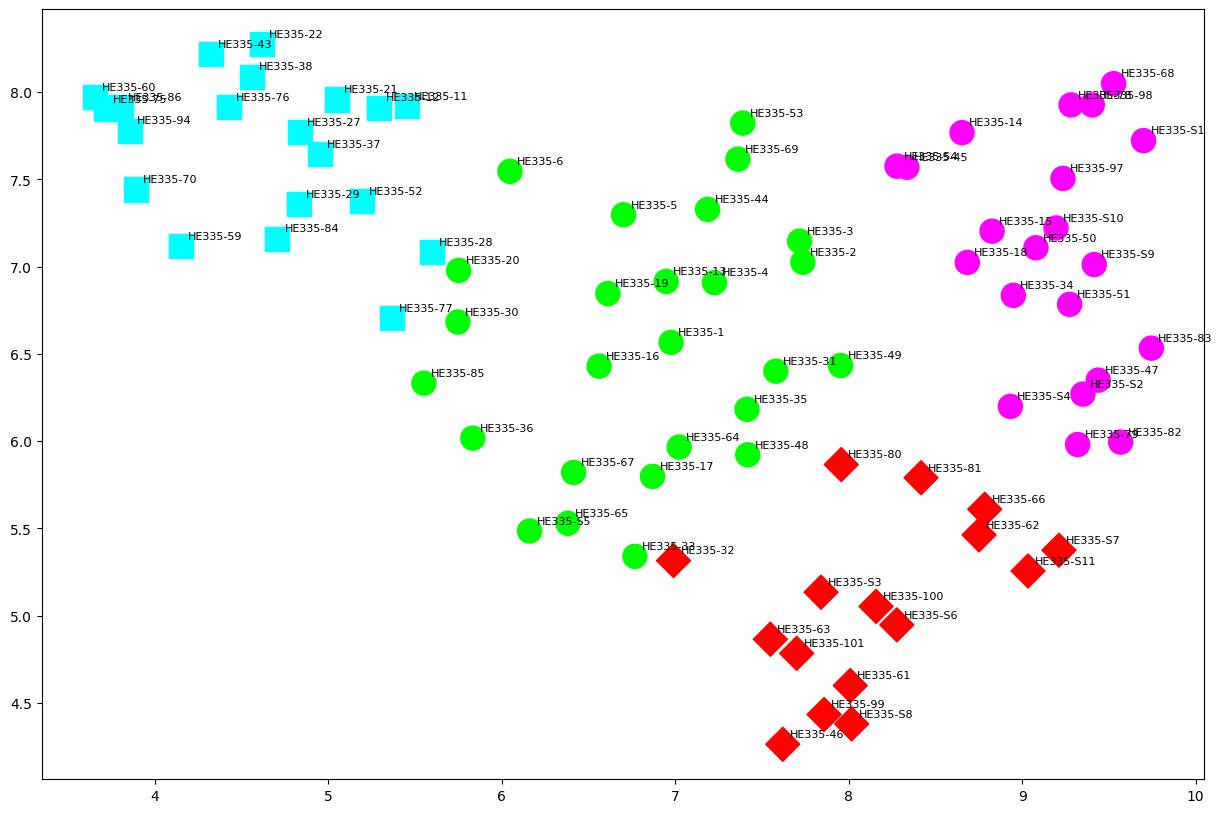

In [19]:
plt.figure(figsize=(15, 10))
for a in ordination_umap['community'].unique():
    subset = ordination_umap.loc[ordination_umap['community']==a]
    e = np.unique(subset['marker'])[0]
    plt.scatter(subset['X'], subset['Y'], c=subset['color'], s=300, marker=e)

for i, label in enumerate(ordination_umap['station']):
    plt.annotate(ordination_umap['station'][i], (ordination_umap['X'][i], ordination_umap['Y'][i]), xytext=(5,5), textcoords='offset points', fontsize=8)
plt.savefig('02_Pictures/32_umap_north_sea.jpg', bbox_inches='tight')
plt.show()

In [20]:
gdf.head()

,station,Latitude,Longitude,Bathy depth [m],Date/Time,A. filiformis [#],A. rubens [#],E. cordatum [#],E. pusillus [#],O. ophiura [#],...,G. vulgaris [#],A. petiolatus [#],N. gracile [#],B. lanceolatum [#],geometry,dominants,number_of_species,total_abundance,cluster,community
0,HE335-1,54.168933,8.170500,21.200000,2010-09-09 08:24:00,33.333333,0.0,0.000000,0.0,66.666667,...,0.0,0.0,0.0,0.0,POINT (8.17050 54.16893),S. inflatum,22,3616.666667,0,S. armiger
1,HE335-100,55.083433,8.000000,18.066667,2010-09-09 17:42:00,0.000000,0.0,16.666667,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (8.00000 55.08343),E. directus,25,4483.333333,3,S. bombyx
2,HE335-101,55.083433,8.165000,16.133333,2010-09-09 16:56:00,0.000000,0.0,16.666667,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (8.16500 55.08343),S. bombyx,21,6816.666667,3,S. bombyx
3,HE335-11,54.248267,7.335333,39.600000,2010-09-11 20:38:00,0.000000,0.0,50.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (7.33533 54.24827),P. muelleri,33,5666.666667,2,P. muelleri
4,HE335-12,54.250000,7.504100,42.033333,2010-09-11 02:17:00,366.666667,0.0,33.333333,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (7.50410 54.25000),P. muelleri,31,6400.000000,2,P. muelleri


In [21]:
stop

NameError: name 'stop' is not defined

# Data from Gebco and Copernicus

This part generaly about make united table from different sources with different resolution - bathymetry from GEBCO, nutrients? production and hydrology from different Copernicus datasets, here i used KDTrees to make united mesh of geographical data, also i used h3 cells again - thats give possibility to use different environmental data for habitat mapping

### Nutrients and production

In [22]:
NC_PATH = 'C:/Users/vladk/NC_DATA/lect/'
NC_PATH = '01_Support_data/'

In [23]:
ds = xr.open_dataset(NC_PATH + 'cmems_mod_glo_bgc_my_0.25deg_P1M-m_1764834669188.nc')
ds = ds.to_dataframe().reset_index()
print(ds.shape)
print(ds.shape)
ds.columns

(2128, 8)
(2128, 8)


Index(['time', 'depth', 'latitude', 'longitude', 'po4', 'o2', 'no3', 'nppv'], dtype='object')

In [24]:
start = 0
for i in np.unique(ds['latitude']):
    for a in np.unique(ds['longitude']):
        tmp = ds.loc[(ds['latitude'] == i) & (ds['longitude'] == a)]
        if len(tmp.dropna()) > 0:
            tmp = tmp.dropna().loc[tmp.dropna()['depth'] == np.max(np.unique(tmp.dropna()['depth']))]
            if start == 0:
                res = tmp
                start = 1
            else: 
                res = pd.concat([res, tmp])
res_chem = res.loc[res['time'] == '2010-09-01']
print(res_chem.shape)
res_chem.head()

(45, 8)


,time,depth,latitude,longitude,po4,o2,no3,nppv
448,2010-09-01,11.773680,53.75,7.25,0.003401,249.257294,4.619812,21.002777
617,2010-09-01,19.429802,53.75,7.50,0.007842,247.774689,3.856394,16.874929
450,2010-09-01,11.773680,53.75,7.75,0.003414,249.518509,5.268805,25.296011
451,2010-09-01,11.773680,53.75,8.00,0.003715,250.041412,5.685365,28.580553
452,2010-09-01,11.773680,53.75,8.25,0.004700,251.071442,6.349272,35.693382


### hydrology

In [25]:
ds = xr.open_dataset(NC_PATH + 'cmems_mod_glo_phy_my_0.083deg_P1M-m_1764835725052.nc')
ds = ds.to_dataframe().reset_index()
print(ds.shape)
ds.columns

(15640, 6)


Index(['time', 'latitude', 'longitude', 'depth', 'bottomT', 'so'], dtype='object')

In [26]:
start = 0
for i in np.unique(ds['latitude']):
    for a in np.unique(ds['longitude']):
        tmp = ds.loc[(ds['latitude'] == i) & (ds['longitude'] == a)]
        if len(tmp.dropna()) > 0:
            tmp = tmp.dropna().loc[tmp.dropna()['depth'] == np.max(np.unique(tmp.dropna()['depth']))]
            if start == 0:
                res = tmp
                start = 1
            else: 
                res = pd.concat([res, tmp])
res_hydro = res.loc[res['time'] == '2010-09-01']
print(res_hydro.shape)
res_hydro.head()

(383, 6)


,time,latitude,longitude,depth,bottomT,so
6,2010-09-01,53.75,7.250010,9.572997,16.531359,32.465591
42,2010-09-01,53.75,7.416677,13.467140,16.305765,31.522568
57,2010-09-01,53.75,7.500010,9.572997,16.136570,31.479843
73,2010-09-01,53.75,7.583344,7.929560,16.093355,30.684835
90,2010-09-01,53.75,7.666677,7.929560,16.027435,30.291147


### bathymetry from GEBCO (NC again)

In [27]:
ds = xr.open_dataset(NC_PATH + 'gebco_2025_n55.3546_s53.7286_w7.2015_e9.1022.nc')
ds = ds.to_dataframe().reset_index()
res_gebco = ds.loc[ds['elevation'] < -1]
print(res_gebco.shape)
res_gebco.head()

(117054, 3)


,lat,lon,elevation
0,53.73125,7.202083,-3
1,53.73125,7.206250,-3
2,53.73125,7.210417,-4
3,53.73125,7.214583,-4
4,53.73125,7.218750,-3


In [28]:
# and opening throw geotiff for more comfortable working with cutted geotiff
def geotiff_to_xyz(way):
    dataarray = rioxarray.open_rasterio(way)
    ds = dataarray[0].to_pandas()
    lat = pd.Series(pd.to_numeric(list(ds.index) * ds.shape[1])).sort_values(ascending=False)
    lon = pd.to_numeric(list(ds.columns) * ds.shape[0])
    depth = ds.values.flatten()
    ds = pd.DataFrame({'lat': lat, 'lon': lon, 'depth': depth})          
    return ds

res_gebco = geotiff_to_xyz("01_Support_data/area_depth_croped.tif")
res_gebco = res_gebco.loc[res_gebco['depth'] != -32767]
print(res_gebco.shape)
res_gebco

(65791, 3)


,lat,lon,depth
42471,55.185417,7.602083,-21
64939,55.185417,7.606250,-20
20003,55.185417,7.610417,-22
8495,55.185417,7.614583,-22
52335,55.185417,7.618750,-20
...,...,...,...
41921,54.052083,8.243750,-13
12877,54.052083,8.247917,-13
42195,54.052083,8.252083,-13
12603,54.052083,8.256250,-13


In [29]:
gdf.columns

Index(['station', 'Latitude', 'Longitude', 'Bathy depth [m]', 'Date/Time',
       'A. filiformis [#]', 'A. rubens [#]', 'E. cordatum [#]',
       'E. pusillus [#]', 'O. ophiura [#]',
       ...
       'G. vulgaris [#]', 'A. petiolatus [#]', 'N. gracile [#]',
       'B. lanceolatum [#]', 'geometry', 'dominants', 'number_of_species',
       'total_abundance', 'cluster', 'community'],
      dtype='object', length=150)

In [30]:
coarse_points = np.c_[res_hydro.longitude.ravel(), res_hydro.latitude.ravel()]
fine_points = np.c_[res_gebco.lon.ravel(), res_gebco.lat.ravel()]

tree = cKDTree(coarse_points)

# distance to gebko points in case of which points from copernicus datasets image will be assigned depth of gebko points

# this is key point in this project. The size of the training sample depends on how many points from the copernicus datasets 
# grid will be assigned depth values from the gebko grid. 
# If the distance is too large (and more points will be assigned values from the gebko grid), 
# the result will be less valid. In addition, if a sequential neural network is used, 
# the model is well trained (and retrained) and the result looks unnatural (all training points are predicted by gebko grid values).

max_distance = 0.1

distances, indices = tree.query(fine_points, distance_upper_bound=max_distance)
fine_values = np.full(fine_points.shape[0], np.nan)
valid_mask = distances < max_distance


united = res_gebco.copy()

for i in ['bottomT', 'so']:
    fine_values[valid_mask] = res_hydro[i].ravel()[indices[valid_mask]]
    fine_values_grid = fine_values.reshape(res_gebco.lon.shape)
    united[i] = fine_values_grid


coarse_points = np.c_[res_chem.longitude.ravel(), res_chem.latitude.ravel()]
fine_points = np.c_[res_gebco.lon.ravel(), res_gebco.lat.ravel()]
tree = cKDTree(coarse_points)
max_distance = 0.2
distances, indices = tree.query(fine_points, distance_upper_bound=max_distance)
fine_values = np.full(fine_points.shape[0], np.nan)
valid_mask = distances < max_distance

for i in ['po4', 'o2', 'no3', 'nppv']:
    fine_values[valid_mask] = res_chem[i].ravel()[indices[valid_mask]]
    fine_values_grid = fine_values.reshape(res_gebco.lon.shape)
    united[i] = fine_values_grid

united = united.dropna()

coarse_points = np.c_[gdf.Longitude.ravel(), gdf.Latitude.ravel()]
fine_points = np.c_[res_gebco.lon.ravel(), res_gebco.lat.ravel()]
tree = cKDTree(coarse_points)
max_distance = 0.02
distances, indices = tree.query(fine_points, distance_upper_bound=max_distance)
fine_values = np.full(fine_points.shape[0], np.nan)
valid_mask = distances < max_distance

for i in ['cluster', 'number_of_species']:
    fine_values[valid_mask] = gdf[i].ravel()[indices[valid_mask]]
    fine_values_grid = fine_values.reshape(res_gebco.lon.shape)
    united[i] = fine_values_grid

C:\Users\v.kozlovskiy\AppData\Local\Temp\ipykernel_12360\3505434216.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  coarse_points = np.c_[res_hydro.longitude.ravel(), res_hydro.latitude.ravel()]
C:\Users\v.kozlovskiy\AppData\Local\Temp\ipykernel_12360\3505434216.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  fine_points = np.c_[res_gebco.lon.ravel(), res_gebco.lat.ravel()]
C:\Users\v.kozlovskiy\AppData\Local\Temp\ipykernel_12360\3505434216.py:24: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  fine_values[valid_mask] = res_hydro[i].ravel()[indices[valid_mask]]
C:\Users\v.kozlovskiy\AppData\Local\Temp\ipykernel_12360\350543

In [31]:
united.head()

,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,cluster,number_of_species
42471,55.185417,7.602083,-21,16.338724,32.090214,0.003323,248.392166,3.369092,11.067895,NaN,NaN
64939,55.185417,7.606250,-20,16.338724,32.090214,0.003323,248.392166,3.369092,11.067895,NaN,NaN
20003,55.185417,7.610417,-22,16.338724,32.090214,0.003323,248.392166,3.369092,11.067895,NaN,NaN
8495,55.185417,7.614583,-22,16.338724,32.090214,0.003323,248.392166,3.369092,11.067895,NaN,NaN
52335,55.185417,7.618750,-20,16.338724,32.090214,0.003323,248.392166,3.369092,11.067895,NaN,NaN


In [32]:
united.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65791 entries, 42471 to 56991
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lat                65791 non-null  float64
 1   lon                65791 non-null  float64
 2   depth              65791 non-null  int16  
 3   bottomT            65791 non-null  float64
 4   so                 65791 non-null  float64
 5   po4                65791 non-null  float64
 6   o2                 65791 non-null  float64
 7   no3                65791 non-null  float64
 8   nppv               65791 non-null  float64
 9   cluster            6048 non-null   float64
 10  number_of_species  6048 non-null   float64
dtypes: float64(10), int16(1)
memory usage: 5.6 MB


In [33]:
united = united.loc[(united['lat'] < 55.17) & (united['lat'] > 54.09)]
united = united.loc[(united['lon'] < 8.24) & (united['lon'] > 7.26)]
united.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61124 entries, 41927 to 59995
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lat                61124 non-null  float64
 1   lon                61124 non-null  float64
 2   depth              61124 non-null  int16  
 3   bottomT            61124 non-null  float64
 4   so                 61124 non-null  float64
 5   po4                61124 non-null  float64
 6   o2                 61124 non-null  float64
 7   no3                61124 non-null  float64
 8   nppv               61124 non-null  float64
 9   cluster            6048 non-null   float64
 10  number_of_species  6048 non-null   float64
dtypes: float64(10), int16(1)
memory usage: 5.2 MB


In [34]:
# and making h3 cells like in file with visualizations
RES_H3 = 6

# function to take h3-index from coordinates 

def convert_to_h3(lat, lon, res):
    h3_index = h3.latlng_to_cell(lat, lon, res)
    return h3_index

def h3_to_table(row):
    lat = row['lat']
    lon = row['lon']
    h3_index = convert_to_h3(lat, lon, RES_H3)
    return h3_index

In [35]:
united['h3'] = united.apply(h3_to_table, axis=1)

In [36]:
gruopby_h3_cluster = united[['cluster','h3']].groupby('h3').agg([pd.Series.mode]).reset_index()
gruopby_h3_cluster.columns = gruopby_h3_cluster.columns.droplevel(1)
gruopby_h3_cluster['cluster'] = gruopby_h3_cluster['cluster'].apply(lambda x: x if x.size == 1 else (9 if x.size == 0 else x[0]))
gruopby_h3_cluster['cluster'] = pd.to_numeric(gruopby_h3_cluster['cluster'])
gruopby_h3_cluster['community'] = gruopby_h3_cluster['cluster'].map(comms)

In [37]:
gruopby_h3 = united.drop('cluster',axis=1).groupby('h3').agg('mean').reset_index()
print(gruopby_h3.shape)
gruopby_h3.head()

(299, 11)


,h3,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,number_of_species
0,861f30007ffffff,54.867192,7.466334,-23.915966,16.655495,32.430455,0.002280,247.399223,3.581174,11.679907,22.0
1,861f3000fffffff,54.860893,7.557874,-22.067797,16.579401,32.058174,0.001988,247.229680,3.664324,11.115177,22.0
2,861f30017ffffff,54.826995,7.401410,-24.289362,16.683603,32.550847,0.001826,247.409852,3.649842,10.796377,NaN
3,861f3001fffffff,54.820470,7.492775,-22.953191,16.650540,32.284141,0.001621,247.016235,3.769006,10.404214,22.0
4,861f30027ffffff,54.913775,7.439671,-24.409283,16.654780,32.628825,0.003686,248.215591,3.180794,14.399148,29.0


In [38]:
gruopby_h3['g_reflect'] = gruopby_h3['h3'].apply(lambda x: h3.cell_to_boundary(x))   # old variant  cellToBoundary 
result_g2 = []
for i in gruopby_h3['g_reflect']:
    iter = []
    for a in i:
        int = tuple([a[1], a[0]])
        iter.append(int)
    iter = tuple(iter)
    c = Polygon(iter)
    polygon = Polygon(iter)
    result_g2.append(c)
gruopby_h3['geometry'] = result_g2
gruopby_h3 = gruopby_h3.drop('g_reflect', axis=1)
gruopby_h3.head()

,h3,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,number_of_species,geometry
0,861f30007ffffff,54.867192,7.466334,-23.915966,16.655495,32.430455,0.002280,247.399223,3.581174,11.679907,22.0,"POLYGON ((7.426973010252081 54.88486911056581,..."
1,861f3000fffffff,54.860893,7.557874,-22.067797,16.579401,32.058174,0.001988,247.229680,3.664324,11.115177,22.0,POLYGON ((7.518538770660467 54.878508478145015...
2,861f30017ffffff,54.826995,7.401410,-24.289362,16.683603,32.550847,0.001826,247.409852,3.649842,10.796377,NaN,POLYGON ((7.361884697653547 54.844559049176794...
3,861f3001fffffff,54.820470,7.492775,-22.953191,16.650540,32.284141,0.001621,247.016235,3.769006,10.404214,22.0,POLYGON ((7.453364427664232 54.838234165470965...
4,861f30027ffffff,54.913775,7.439671,-24.409283,16.654780,32.628825,0.003686,248.215591,3.180794,14.399148,29.0,"POLYGON ((7.400545064124199 54.93145495476257,..."


In [39]:
gruopby_h3 = gruopby_h3.merge(gruopby_h3_cluster[['h3','community']], on='h3')

In [40]:
united['community'] = united['cluster'].map(comms)
united.head()

,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,cluster,number_of_species,h3,community
41927,55.16875,7.260417,-22,16.419294,32.432018,0.00348,251.114578,2.340339,11.480175,NaN,NaN,861f30807ffffff,NaN
42749,55.16875,7.264583,-22,16.419294,32.432018,0.00348,251.114578,2.340339,11.480175,NaN,NaN,861f30807ffffff,NaN
51243,55.16875,7.268750,-22,16.419294,32.432018,0.00348,251.114578,2.340339,11.480175,NaN,NaN,861f30807ffffff,NaN
43023,55.16875,7.272917,-22,16.419294,32.432018,0.00348,251.114578,2.340339,11.480175,NaN,NaN,861f30807ffffff,NaN
27405,55.16875,7.277083,-23,16.419294,32.432018,0.00348,251.114578,2.340339,11.480175,NaN,NaN,861f30807ffffff,NaN


In [41]:
united = gpd.GeoDataFrame(
    united, geometry=gpd.points_from_xy(united.lon, united.lat), crs="EPSG:4326"
)
united.head()

,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,cluster,number_of_species,h3,community,geometry
41927,55.16875,7.260417,-22,16.419294,32.432018,0.00348,251.114578,2.340339,11.480175,NaN,NaN,861f30807ffffff,NaN,POINT (7.26042 55.16875)
42749,55.16875,7.264583,-22,16.419294,32.432018,0.00348,251.114578,2.340339,11.480175,NaN,NaN,861f30807ffffff,NaN,POINT (7.26458 55.16875)
51243,55.16875,7.268750,-22,16.419294,32.432018,0.00348,251.114578,2.340339,11.480175,NaN,NaN,861f30807ffffff,NaN,POINT (7.26875 55.16875)
43023,55.16875,7.272917,-22,16.419294,32.432018,0.00348,251.114578,2.340339,11.480175,NaN,NaN,861f30807ffffff,NaN,POINT (7.27292 55.16875)
27405,55.16875,7.277083,-23,16.419294,32.432018,0.00348,251.114578,2.340339,11.480175,NaN,NaN,861f30807ffffff,NaN,POINT (7.27708 55.16875)


In [42]:
# selection of data where we have data about community and haven't
united_prod = united.loc[united.cluster.isna() == True].reset_index(drop=True)
united_ml = united.loc[united.cluster.isna() == False].reset_index(drop=True)
print(united.shape, united_prod.shape, united_ml.shape)

(61124, 14) (55076, 14) (6048, 14)


In [43]:
gruopby_h3 = gpd.GeoDataFrame(gruopby_h3, geometry=gruopby_h3['geometry'], crs="EPSG:4326")
gruopby_h3

,h3,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,number_of_species,geometry,community
0,861f30007ffffff,54.867192,7.466334,-23.915966,16.655495,32.430455,0.002280,247.399223,3.581174,11.679907,22.0,"POLYGON ((7.42697 54.88487, 7.41407 54.85590, ...",S. armiger
1,861f3000fffffff,54.860893,7.557874,-22.067797,16.579401,32.058174,0.001988,247.229680,3.664324,11.115177,22.0,"POLYGON ((7.51854 54.87851, 7.50559 54.84954, ...",S. armiger
2,861f30017ffffff,54.826995,7.401410,-24.289362,16.683603,32.550847,0.001826,247.409852,3.649842,10.796377,NaN,"POLYGON ((7.36188 54.84456, 7.34902 54.81557, ...",NaN
3,861f3001fffffff,54.820470,7.492775,-22.953191,16.650540,32.284141,0.001621,247.016235,3.769006,10.404214,22.0,"POLYGON ((7.45336 54.83823, 7.44046 54.80924, ...",S. armiger
4,861f30027ffffff,54.913775,7.439671,-24.409283,16.654780,32.628825,0.003686,248.215591,3.180794,14.399148,29.0,"POLYGON ((7.40055 54.93145, 7.38765 54.90250, ...",P. muelleri
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,861f33d97ffffff,54.142080,7.521598,-36.388186,16.970185,33.686226,0.046664,246.554960,2.446651,17.614056,24.0,"POLYGON ((7.48267 54.15991, 7.46988 54.13061, ...",S. armiger
295,861f33d9fffffff,54.135222,7.611935,-35.326271,16.939307,33.647401,0.043095,245.298757,2.699127,18.112470,NaN,"POLYGON ((7.57319 54.15324, 7.56036 54.12395, ...",NaN
296,861f33da7ffffff,54.229674,7.559489,-38.575630,16.940489,33.479703,0.048537,246.733383,2.422330,17.982534,31.0,"POLYGON ((7.52110 54.24771, 7.50828 54.21846, ...",P. muelleri
297,861f33dafffffff,54.223111,7.650565,-37.627119,16.965831,33.416663,0.046170,243.283416,3.032155,21.100378,35.0,"POLYGON ((7.61176 54.24105, 7.59889 54.21180, ...",S. armiger


In [44]:
gdf.head()

,station,Latitude,Longitude,Bathy depth [m],Date/Time,A. filiformis [#],A. rubens [#],E. cordatum [#],E. pusillus [#],O. ophiura [#],...,G. vulgaris [#],A. petiolatus [#],N. gracile [#],B. lanceolatum [#],geometry,dominants,number_of_species,total_abundance,cluster,community
0,HE335-1,54.168933,8.170500,21.200000,2010-09-09 08:24:00,33.333333,0.0,0.000000,0.0,66.666667,...,0.0,0.0,0.0,0.0,POINT (8.17050 54.16893),S. inflatum,22,3616.666667,0,S. armiger
1,HE335-100,55.083433,8.000000,18.066667,2010-09-09 17:42:00,0.000000,0.0,16.666667,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (8.00000 55.08343),E. directus,25,4483.333333,3,S. bombyx
2,HE335-101,55.083433,8.165000,16.133333,2010-09-09 16:56:00,0.000000,0.0,16.666667,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (8.16500 55.08343),S. bombyx,21,6816.666667,3,S. bombyx
3,HE335-11,54.248267,7.335333,39.600000,2010-09-11 20:38:00,0.000000,0.0,50.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (7.33533 54.24827),P. muelleri,33,5666.666667,2,P. muelleri
4,HE335-12,54.250000,7.504100,42.033333,2010-09-11 02:17:00,366.666667,0.0,33.333333,0.0,0.000000,...,0.0,0.0,0.0,0.0,POINT (7.50410 54.25000),P. muelleri,31,6400.000000,2,P. muelleri


In [45]:
gdf.groupby('community')['station'].agg(['count']).to_dict()['count']

{'E. directus': 21, 'P. muelleri': 20, 'S. armiger': 26, 'S. bombyx': 16}

In [46]:
united_ml.head()

,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,cluster,number_of_species,h3,community,geometry
0,55.102083,7.327083,-24,16.523300,32.422863,0.003588,252.529312,2.295518,13.839728,2.0,32.0,861f308f7ffffff,P. muelleri,POINT (7.32708 55.10208)
1,55.102083,7.331250,-24,16.523300,32.422863,0.003588,252.529312,2.295518,13.839728,2.0,32.0,861f308f7ffffff,P. muelleri,POINT (7.33125 55.10208)
2,55.102083,7.335417,-24,16.523300,32.422863,0.003588,252.529312,2.295518,13.839728,2.0,32.0,861f308f7ffffff,P. muelleri,POINT (7.33542 55.10208)
3,55.102083,7.339583,-24,16.523300,32.422863,0.003588,252.529312,2.295518,13.839728,2.0,32.0,861f308f7ffffff,P. muelleri,POINT (7.33958 55.10208)
4,55.102083,7.497917,-21,16.395123,32.113102,0.003686,248.215591,3.180794,14.399148,1.0,13.0,861f308cfffffff,E. directus,POINT (7.49792 55.10208)


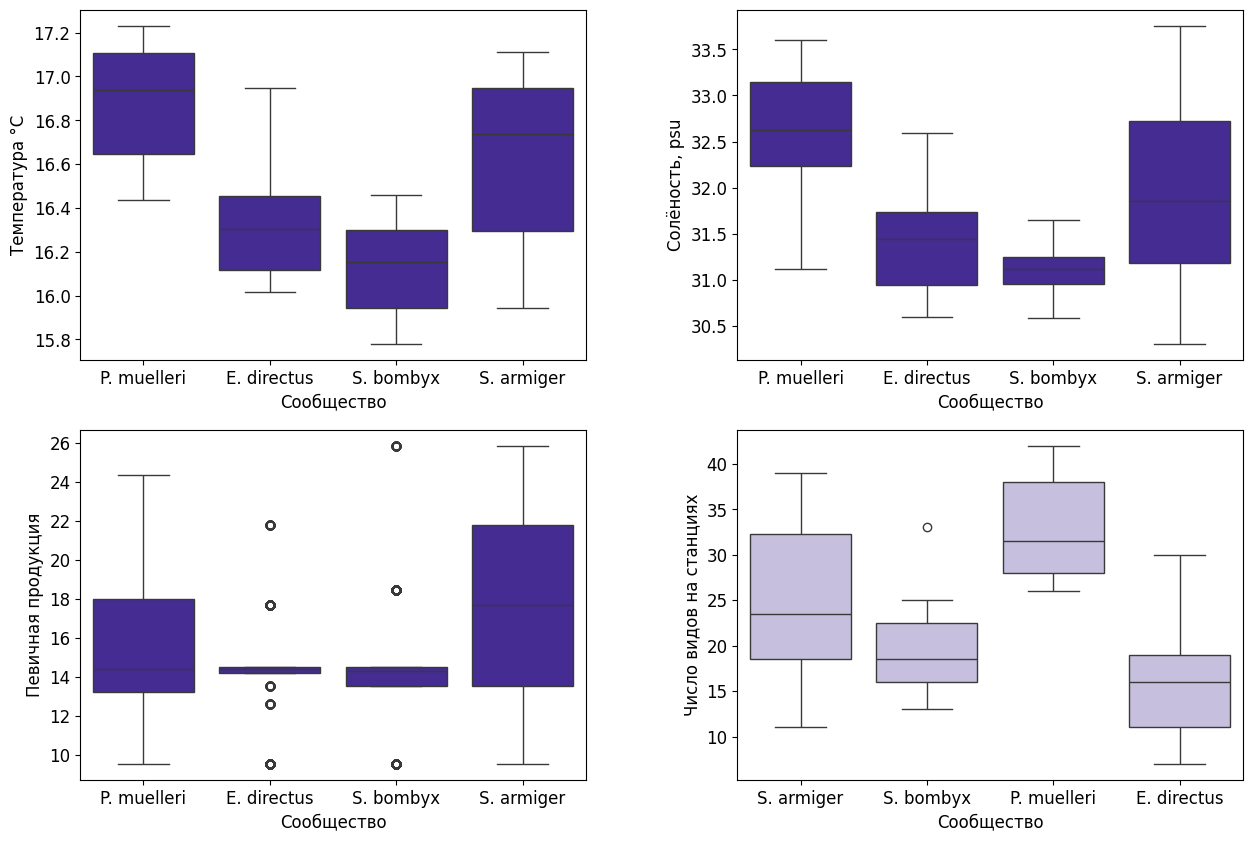

In [47]:
# visualization for this "like synthetic case"

plt.figure(figsize=(15, 10))

plt.subplot(221)
sns.boxplot(x='community', y='bottomT', data=united_ml, color='#3C1BA3')
plt.xlabel('Сообщество', fontsize=12)
plt.ylabel('Температура °С', fontsize=12)
plt.xticks(fontsize = 12) #, position = (-0.03, 0), rotation = 60)
plt.yticks(fontsize = 12)

plt.subplot(222)
sns.boxplot(x='community', y='so', data=united_ml, color='#3C1BA3')
plt.xlabel('Сообщество', fontsize=12)
plt.ylabel('Солёность, psu', fontsize=12)
plt.xticks(fontsize = 12) #, position = (-0.03, 0), rotation = 60)
plt.yticks(fontsize = 12)

plt.subplot(223)
sns.boxplot(x='community', y='nppv', data=united_ml, color='#3C1BA3')
plt.xlabel('Сообщество', fontsize=12)
plt.ylabel('Певичная продукция', fontsize=12)
plt.xticks(fontsize = 12) #, position = (-0.03, 0), rotation = 60)
plt.yticks(fontsize = 12)


plt.subplot(224)
ax = sns.boxplot(x='community', y='number_of_species', data=gdf, color='#3C1BA3')
for patch in ax.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .3))
plt.xlabel('Сообщество', fontsize=12)
plt.ylabel('Число видов на станциях', fontsize=12)
plt.xticks(fontsize = 12) #, position = (-0.03, 0), rotation = 60)
plt.yticks(fontsize = 12)


plt.savefig('02_Pictures/33_boxplots_north_sea.jpg', bbox_inches='tight')
plt.subplots_adjust(hspace=0.2, wspace=0.3)
plt.show()

In [48]:
# saving data for ml support of habitat mapping 
# previously i usually used .geojson, now i try to use parquet due it is more compactable
'''
gruopby_h3.to_file('04_ml_proc/grouped_north_sea_h3_' + str(RES_H3) + '.geojson', driver="GeoJSON")
united_ml.to_file('04_ml_proc/united_north_sea_ml.geojson', driver="GeoJSON")
united_prod.to_file('04_ml_proc/united_north_sea_for_prod.geojson', driver="GeoJSON")
gdf.to_file('04_ml_proc/HE335.geojson', driver="GeoJSON")
'''

gruopby_h3.to_parquet('04_ml_proc/grouped_north_sea_h3_' + str(RES_H3) + '.parquet')
united_ml.to_parquet('04_ml_proc/united_north_sea_ml.parquet')
united_prod.to_parquet('04_ml_proc/united_north_sea_for_prod.parquet')
gdf.to_parquet('04_ml_proc/HE335.parquet')

In [ ]:
stop

NameError: name 'stop' is not defined

# ML part

In [2]:
data = gpd.read_parquet('04_ml_proc/united_north_sea_ml.parquet')
data

,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,cluster,number_of_species,h3,community,geometry
0,55.102083,7.327083,-24,16.523300,32.422863,0.003588,252.529312,2.295518,13.839728,2.0,32.0,861f308f7ffffff,P. muelleri,POINT (7.32708 55.10208)
1,55.102083,7.331250,-24,16.523300,32.422863,0.003588,252.529312,2.295518,13.839728,2.0,32.0,861f308f7ffffff,P. muelleri,POINT (7.33125 55.10208)
2,55.102083,7.335417,-24,16.523300,32.422863,0.003588,252.529312,2.295518,13.839728,2.0,32.0,861f308f7ffffff,P. muelleri,POINT (7.33542 55.10208)
3,55.102083,7.339583,-24,16.523300,32.422863,0.003588,252.529312,2.295518,13.839728,2.0,32.0,861f308f7ffffff,P. muelleri,POINT (7.33958 55.10208)
4,55.102083,7.497917,-21,16.395123,32.113102,0.003686,248.215591,3.180794,14.399148,1.0,13.0,861f308cfffffff,E. directus,POINT (7.49792 55.10208)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6043,54.147917,7.831250,-49,16.937864,33.497116,0.045642,242.514771,3.168023,21.795027,0.0,35.0,861f33c1fffffff,S. armiger,POINT (7.83125 54.14792)
6044,54.147917,7.835417,-49,16.937864,33.497116,0.045642,242.514771,3.168023,21.795027,0.0,35.0,861f33c1fffffff,S. armiger,POINT (7.83542 54.14792)
6045,54.147917,7.839583,-50,16.937864,33.497116,0.045642,242.514771,3.168023,21.795027,0.0,35.0,861f33c1fffffff,S. armiger,POINT (7.83958 54.14792)
6046,54.147917,7.997917,-35,16.878536,33.240761,0.006629,246.718842,4.382689,17.688961,0.0,36.0,861f33cefffffff,S. armiger,POINT (7.99792 54.14792)


In [3]:
comm_dict_reserv = data.set_index('cluster')['community'].to_dict()
comm_dict_reserv

{2.0: 'P. muelleri', 1.0: 'E. directus', 3.0: 'S. bombyx', 0.0: 'S. armiger'}

In [4]:
# ml libraries
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
            
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression

#from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
#from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif  
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, KBinsDiscretizer, OrdinalEncoder, StandardScaler, PowerTransformer

from sklearn.model_selection import cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, mean_absolute_error, mean_absolute_percentage_error, r2_score

### Classification (for benthic communities)

In [5]:
data.columns

Index(['lat', 'lon', 'depth', 'bottomT', 'so', 'po4', 'o2', 'no3', 'nppv',
       'cluster', 'number_of_species', 'h3', 'community', 'geometry'],
      dtype='object')

In [6]:
# here selection of features and target (k-means class) than data split to train and test

X = data.drop(['cluster', 'number_of_species', 'h3', 'community', 'geometry'], axis=1)
y = data['cluster']

X = X.drop(['po4', 'o2', 'no3', 'nppv','lat','lon'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345, stratify=y)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4838, 3)
(4838,)
(1210, 3)
(1210,)


In [7]:
# some transformations for light feature engineering and than scaling

feature_maker = ColumnTransformer([
    ('poly', PolynomialFeatures(degree=4, include_bias=False), list(X.columns)),
    ('pwr', PowerTransformer(method='yeo-johnson'),  list(X.columns)),
    ('kbins', KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='uniform', subsample=None), list(X.columns))
    ])

power_transformer = Pipeline(steps=[
    ('f_make', feature_maker),
    ('scaler', StandardScaler())  
])

In [8]:
power_transformer.fit(X_train)

X_train_sc = pd.DataFrame(power_transformer.transform(X_train), columns=power_transformer.get_feature_names_out())
X_test_sc = pd.DataFrame(power_transformer.transform(X_test), columns=power_transformer.get_feature_names_out())
X_train_sc.head()

,poly__depth,poly__bottomT,poly__so,poly__depth^2,poly__depth bottomT,poly__depth so,poly__bottomT^2,poly__bottomT so,poly__so^2,poly__depth^3,...,poly__bottomT^3 so,poly__bottomT^2 so^2,poly__bottomT so^3,poly__so^4,pwr__depth,pwr__bottomT,pwr__so,kbins__depth,kbins__bottomT,kbins__so
0,0.843021,-1.468305,-0.878387,-0.750235,0.872950,0.838905,-1.453592,-1.193879,-0.875249,0.627814,...,-1.315458,-1.173518,-1.018677,-0.868043,0.846912,-1.495630,-0.892671,0.945399,-1.620605,-0.845012
1,0.084318,0.230737,-0.943999,-0.229056,0.084242,0.163736,0.219454,-0.447296,-0.938694,0.310541,...,-0.149467,-0.463227,-0.723944,-0.927239,-0.076583,0.251528,-0.976563,0.064459,-0.014496,-0.845012
2,-1.306638,1.727555,1.453358,1.204188,-1.369566,-1.325624,1.749458,1.676802,1.458551,-1.004850,...,1.779704,1.707370,1.596110,1.467360,-1.270149,1.687000,1.383339,-1.697420,1.591613,1.335054
3,0.337219,-0.842740,-0.198717,-0.423220,0.379145,0.345405,-0.845472,-0.521974,-0.210861,0.441410,...,-0.699040,-0.535507,-0.376887,-0.234505,0.200848,-0.836950,-0.079290,0.064459,-1.085236,-0.299996
4,0.210768,-0.211506,-0.641175,-0.328693,0.228158,0.257728,-0.222540,-0.477856,-0.644856,0.379417,...,-0.377812,-0.492839,-0.583668,-0.651170,0.058955,-0.190671,-0.593580,0.064459,-0.014496,-0.845012


In [9]:
# option with just scaling without additional features
'''
scaler = StandardScaler()

scaler.fit(X_train)    

X_train_sc = pd.DataFrame(scaler.transform(X_train), columns=scaler.get_feature_names_out())
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=scaler.get_feature_names_out())
X_train_sc.head()
'''

'\nscaler = StandardScaler()\n\nscaler.fit(X_train)    \n\nX_train_sc = pd.DataFrame(scaler.transform(X_train), columns=scaler.get_feature_names_out())\nX_test_sc = pd.DataFrame(scaler.transform(X_test), columns=scaler.get_feature_names_out())\nX_train_sc.head()\n'

In [10]:
y_train.value_counts()

cluster
0.0    1514
1.0    1228
2.0    1156
3.0     940
Name: count, dtype: int64

In [11]:
# reduce class imbalance
sampler = RandomOverSampler(random_state=SEED)

X_train_oversampled, y_train_oversampled = sampler.fit_resample(X_train_sc, y_train)

print(X_train_oversampled.shape)
print(y_train_oversampled.shape)
y_train_oversampled.value_counts()

(6056, 40)
(6056,)


cluster
3.0    1514
0.0    1514
2.0    1514
1.0    1514
Name: count, dtype: int64

Below i want to find best hyperparams to each type of models and than add best models of each type to list - final model will be choosen using test data

In [12]:
models = []

In [13]:
clf = LogisticRegression(random_state=SEED, class_weight='balanced', penalty='elasticnet', multi_class='multinomial',solver='saga',max_iter=300)
parametrs = {'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
             'C' : [0.001, 0.01,0.5, 0.1, 0.5,1,2,5,10,100]}

      #      'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']}
           # 'solver': ['sag', 'saga']}
           
random_cv = RandomizedSearchCV(estimator=clf,
    param_distributions=parametrs,
    cv=3, n_iter=50, 
    scoring = 'roc_auc_ovr_weighted',
    n_jobs = -1, verbose = 0, 
    return_train_score = True,
    random_state=SEED)

random_cv.fit(X_train_oversampled, y_train_oversampled)

best_ridge = random_cv.best_estimator_
models.append(best_ridge)
print(best_ridge)

best_ridge_score = random_cv.best_score_
print(best_ridge_score)

LogisticRegression(C=100, class_weight='balanced', l1_ratio=0.9, max_iter=300,
                   multi_class='multinomial', penalty='elasticnet',
                   random_state=171225, solver='saga')
0.874529663195418


c:\Users\v.kozlovskiy\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [14]:
prediction = best_ridge.predict(X_test_sc)
print(f1_score(prediction, y_test, average='weighted'))
print(accuracy_score(prediction, y_test))
preds = best_ridge.predict_proba(X_test_sc)
print(roc_auc_score(y_test, preds, multi_class='ovr'))

0.6756059337053868
0.6644628099173554
0.8643665731172963


In [15]:
clf = RandomForestClassifier(random_state=SEED)
parametrs = { 'max_depth': range (1, 50, 2),
            'n_estimators': range (1, 50, 2),
            'min_samples_split':range(2, 50, 2),
            'min_samples_leaf':range(1, 50, 2)}

random_cv = RandomizedSearchCV(estimator=clf,
    param_distributions=parametrs,
    cv=2, n_iter=20, 
    scoring = 'roc_auc_ovr_weighted',
    n_jobs = -1, verbose = 2, 
    return_train_score = True,
    random_state=SEED)

random_cv.fit(X_train_oversampled, y_train_oversampled)

best_forest = random_cv.best_estimator_
models.append(best_forest)
print(best_forest)

best_forest_score = random_cv.best_score_
print(best_forest_score)

Fitting 2 folds for each of 20 candidates, totalling 40 fits
RandomForestClassifier(max_depth=13, min_samples_leaf=3, min_samples_split=6,
                       n_estimators=49, random_state=171225)
0.9996676404053872


In [16]:
clf = DecisionTreeClassifier(random_state=SEED)
parametrs = { 'max_depth': range (1, 50, 2),
            'min_samples_split':range(2, 50, 2),
            'min_samples_leaf':range(1, 50, 2)}

random_cv = RandomizedSearchCV(estimator=clf,
    param_distributions=parametrs,
    cv=2, n_iter=20, 
    scoring = 'roc_auc_ovr_weighted',
    n_jobs = -1, verbose = 2, 
    return_train_score = True,
    random_state=SEED)

random_cv.fit(X_train_oversampled, y_train_oversampled)

best_tree = random_cv.best_estimator_
models.append(best_tree)
print(best_tree)

best_tree_score = random_cv.best_score_
print(best_tree_score)

Fitting 2 folds for each of 20 candidates, totalling 40 fits
DecisionTreeClassifier(max_depth=39, min_samples_leaf=9, min_samples_split=10,
                       random_state=171225)
0.9987223678370727


In [17]:
model_dummy = DummyClassifier(strategy="most_frequent")
model_dummy.fit(X_train_sc, y_train)

models.append(model_dummy)

prediction = model_dummy.predict(X_test_sc)
print(f1_score(prediction, y_test, average='weighted'))
print(accuracy_score(prediction, y_test))
preds = best_ridge.predict_proba(X_test_sc)
print(roc_auc_score(y_test, preds, multi_class='ovr'))

0.47702957835116433
0.31322314049586775
0.8643665731172963


In [18]:
models

[LogisticRegression(C=100, class_weight='balanced', l1_ratio=0.9, max_iter=300,
                    multi_class='multinomial', penalty='elasticnet',
                    random_state=171225, solver='saga'),
 RandomForestClassifier(max_depth=13, min_samples_leaf=3, min_samples_split=6,
                        n_estimators=49, random_state=171225),
 DecisionTreeClassifier(max_depth=39, min_samples_leaf=9, min_samples_split=10,
                        random_state=171225),
 DummyClassifier(strategy='most_frequent')]

In [19]:
import time

score_list_f1 = []
predictions_list = []
score_list_acc = []
time_list = []
score_list_roc_auc = []
models_list = ['linear','forest','tree','dummy']

for i in models:
    print(i)
    tic = time.time()
    predictions = i.predict(X_test_sc)
    predictions_list.append(predictions.reshape(len(predictions),))
    tac = time.time()
    time_int = tac - tic 

    score_list_f1.append(f1_score(predictions, y_test, average='weighted'))
    score_list_acc.append(accuracy_score(predictions, y_test))
    score_list_roc_auc.append(roc_auc_score(y_test, i.predict_proba(X_test_sc), multi_class='ovr'))
    time_list.append(time_int)


LogisticRegression(C=100, class_weight='balanced', l1_ratio=0.9, max_iter=300,
                   multi_class='multinomial', penalty='elasticnet',
                   random_state=171225, solver='saga')
RandomForestClassifier(max_depth=13, min_samples_leaf=3, min_samples_split=6,
                       n_estimators=49, random_state=171225)
DecisionTreeClassifier(max_depth=39, min_samples_leaf=9, min_samples_split=10,
                       random_state=171225)
DummyClassifier(strategy='most_frequent')


In [20]:
# table for compare results
pd.options.display.float_format = '{:,.4f}'.format  

table_mae = pd.DataFrame(data=[models, score_list_f1, score_list_acc, score_list_roc_auc, time_list], columns=models_list, index=['models','f1', 'accuracy', 'roc-auc', 'время, с'])
table_mae = table_mae.T
table_mae = table_mae.sort_values(by='f1', ascending=False)
table_mae['model'] = table_mae.index
#table_mae.to_excel('table_compare_models.xlsx')
table_mae

,models,f1,accuracy,roc-auc,"время, с",model
forest,"(DecisionTreeClassifier(max_depth=13, max_feat...",0.9859,0.9860,0.9995,0.0060,forest
tree,"DecisionTreeClassifier(max_depth=39, min_sampl...",0.9768,0.9769,0.9987,0.0020,tree
linear,"LogisticRegression(C=100, class_weight='balanc...",0.6756,0.6645,0.8644,0.0020,linear
dummy,DummyClassifier(strategy='most_frequent'),0.4770,0.3132,0.5000,0.0000,dummy


In [21]:
table_predictions = pd.DataFrame(data=predictions_list, 
                                 index=models_list)

table_predictions = table_predictions.T
table_predictions = table_predictions.set_index(y_test.index)
table_predictions['true'] = y_test
table_predictions.head()

,linear,forest,tree,dummy,true
608,2.0000,2.0000,2.0000,0.0000,2.0000
3861,3.0000,3.0000,3.0000,0.0000,3.0000
100,3.0000,3.0000,3.0000,0.0000,3.0000
1469,3.0000,1.0000,1.0000,0.0000,1.0000
3230,1.0000,3.0000,3.0000,0.0000,1.0000


In [22]:
best_modle_from_survey = table_mae['models'][0]
print(best_modle_from_survey)
best_model_name = list(table_mae['model'].iloc[:1])[0]
print(best_model_name)

RandomForestClassifier(max_depth=13, min_samples_leaf=3, min_samples_split=6,
                       n_estimators=49, random_state=171225)
forest


C:\Users\v.kozlovskiy\AppData\Local\Temp\ipykernel_12836\619948583.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_modle_from_survey = table_mae['models'][0]


Text(0.5, 1.0, 'Важность признаков: forest')

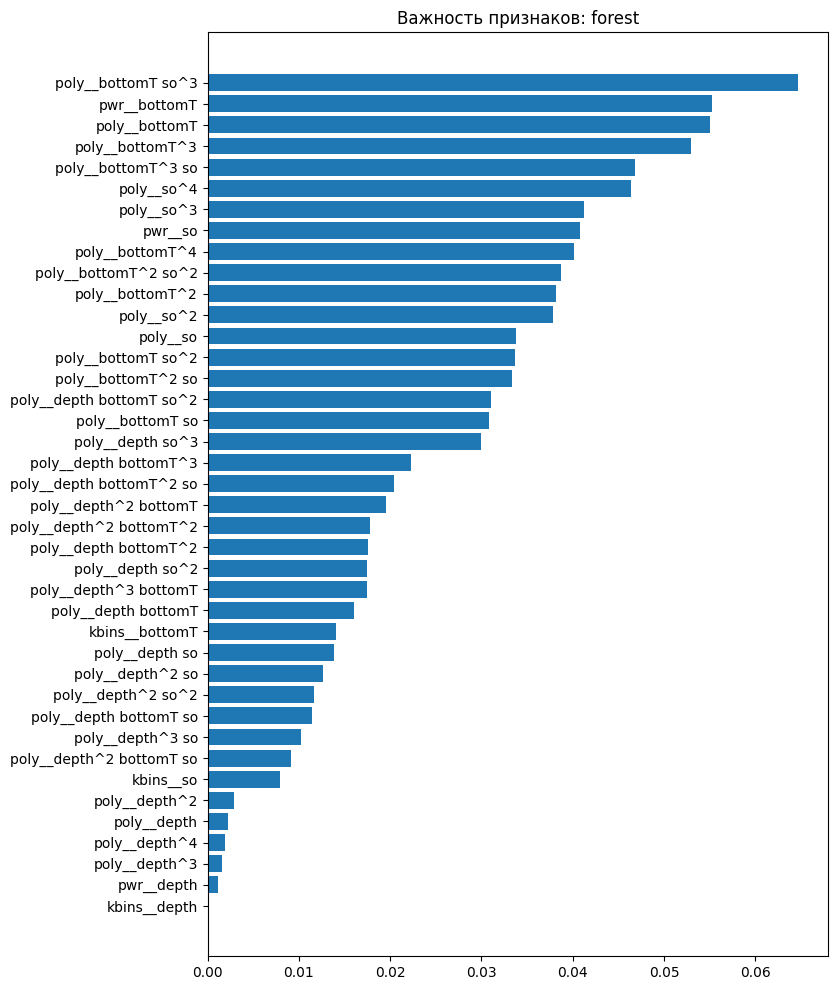

In [23]:
# feature importance plot
feature_importance = best_modle_from_survey.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(8, 12))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X_test_sc.columns)[sorted_idx], fontsize=10)
plt.title(f"Важность признаков: {best_model_name}")

In [24]:
for_prod = gpd.read_parquet('04_ml_proc/united_north_sea_for_prod.parquet')
for_prod.head()

,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,cluster,number_of_species,h3,community,geometry
0,55.1687,7.2604,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,NaN,NaN,861f30807ffffff,None,POINT (7.26042 55.16875)
1,55.1687,7.2646,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,NaN,NaN,861f30807ffffff,None,POINT (7.26458 55.16875)
2,55.1687,7.2687,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,NaN,NaN,861f30807ffffff,None,POINT (7.26875 55.16875)
3,55.1687,7.2729,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,NaN,NaN,861f30807ffffff,None,POINT (7.27292 55.16875)
4,55.1687,7.2771,-23,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,NaN,NaN,861f30807ffffff,None,POINT (7.27708 55.16875)


In [25]:
X_for_prod = for_prod.drop(['cluster', 'number_of_species', 'h3', 'community', 'geometry'], axis=1)
X_for_prod = X_for_prod.drop(['po4', 'o2', 'no3', 'nppv', 'lat','lon'], axis=1)
X_for_prod = pd.DataFrame(power_transformer.transform(X_for_prod), columns=power_transformer.get_feature_names_out())
X_for_prod.head()

,poly__depth,poly__bottomT,poly__so,poly__depth^2,poly__depth bottomT,poly__depth so,poly__bottomT^2,poly__bottomT so,poly__so^2,poly__depth^3,...,poly__bottomT^3 so,poly__bottomT^2 so^2,poly__bottomT so^3,poly__so^4,pwr__depth,pwr__bottomT,pwr__so,kbins__depth,kbins__bottomT,kbins__so
0,-0.1686,-0.2417,0.6610,-0.0145,-0.1272,-0.1792,-0.2526,0.2525,0.6482,0.1507,...,-0.0176,0.2274,0.4428,0.6216,-0.3308,-0.2212,0.7596,0.0645,-0.0145,0.7900
1,-0.1686,-0.2417,0.6610,-0.0145,-0.1272,-0.1792,-0.2526,0.2525,0.6482,0.1507,...,-0.0176,0.2274,0.4428,0.6216,-0.3308,-0.2212,0.7596,0.0645,-0.0145,0.7900
2,-0.1686,-0.2417,0.6610,-0.0145,-0.1272,-0.1792,-0.2526,0.2525,0.6482,0.1507,...,-0.0176,0.2274,0.4428,0.6216,-0.3308,-0.2212,0.7596,0.0645,-0.0145,0.7900
3,-0.1686,-0.2417,0.6610,-0.0145,-0.1272,-0.1792,-0.2526,0.2525,0.6482,0.1507,...,-0.0176,0.2274,0.4428,0.6216,-0.3308,-0.2212,0.7596,0.0645,-0.0145,0.7900
4,-0.2950,-0.2417,0.6610,0.1005,-0.2462,-0.2975,-0.2526,0.2525,0.6482,0.0590,...,-0.0176,0.2274,0.4428,0.6216,-0.4504,-0.2212,0.7596,0.0645,-0.0145,0.7900


In [26]:
for_prod['cluster'] = best_modle_from_survey.predict(X_for_prod)
for_prod['community'] = for_prod['cluster'].map(comm_dict_reserv)
for_prod.head()

,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,cluster,number_of_species,h3,community,geometry
0,55.1687,7.2604,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.26042 55.16875)
1,55.1687,7.2646,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.26458 55.16875)
2,55.1687,7.2687,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.26875 55.16875)
3,55.1687,7.2729,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.27292 55.16875)
4,55.1687,7.2771,-23,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,2.0000,NaN,861f30807ffffff,P. muelleri,POINT (7.27708 55.16875)


In [27]:
for_prod.to_parquet('04_ml_proc/united_north_sea_after_prod.parquet')

In [28]:
# function for convert gdf to georaster
def gdf_to_raster(data, param, name='output'):
    # define the resolution and bounds
    data = data.to_crs(data.estimate_utm_crs())
    # set pixel size as required
    pixel_size = 100 
    # get bounds of the geodata
    bounds = data.total_bounds  
    left, bottom, right, top = bounds

    # compute raster width and height

    width = (right - left) / pixel_size
    width = width.astype('int')
    height = (top - bottom) / pixel_size
    height = height.astype('int')

    # define transform
    transform = from_bounds(left, bottom, right, top, width, height)

    # prepare shapes with values
    shapes = ((geom, value) for geom, value in zip(data.geometry, data[param]))

    # rasterize
    raster = rasterize(
        shapes=shapes,
        out_shape=(height, width),
        transform=transform,
        # background value (for areas without data)
        fill=5,  
        dtype='float32' 
    )

    # metadata for the output raster
    out_meta = {
        'driver': 'GTiff',
        'height': height,
        'width': width,
        'count': 1,
        'dtype': raster.dtype,
        'crs': data.crs,
        'transform': transform,
    }

    # write to GeoTIFF
    with rasterio.open(name + '.tif', 'w', **out_meta) as dest:
        dest.write(raster, 1)

In [29]:
def reproject_raster(path, name_output='output_geographic'):
    input_raster = path  

    # open raster
    with rasterio.open(input_raster) as src:
        # define the target CRS 
        dst_crs = 'EPSG:4326'
    
        # calculate the transform and dimensions for the new raster
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
    
        # update metadata for the output file
        out_meta = src.meta.copy()
        out_meta.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })
    # define the output filename 
    output_raster = name_output + '.tif'

    with rasterio.open(input_raster) as src:
        with rasterio.open(output_raster, 'w', **out_meta) as dest:
            # perform the reproject operation
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dest, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest  
            )


In [30]:
for_prod.head()

,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,cluster,number_of_species,h3,community,geometry
0,55.1687,7.2604,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.26042 55.16875)
1,55.1687,7.2646,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.26458 55.16875)
2,55.1687,7.2687,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.26875 55.16875)
3,55.1687,7.2729,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.27292 55.16875)
4,55.1687,7.2771,-23,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,2.0000,NaN,861f30807ffffff,P. muelleri,POINT (7.27708 55.16875)


In [31]:
data.head()

,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,cluster,number_of_species,h3,community,geometry
0,55.1021,7.3271,-24,16.5233,32.4229,0.0036,252.5293,2.2955,13.8397,2.0000,32.0000,861f308f7ffffff,P. muelleri,POINT (7.32708 55.10208)
1,55.1021,7.3312,-24,16.5233,32.4229,0.0036,252.5293,2.2955,13.8397,2.0000,32.0000,861f308f7ffffff,P. muelleri,POINT (7.33125 55.10208)
2,55.1021,7.3354,-24,16.5233,32.4229,0.0036,252.5293,2.2955,13.8397,2.0000,32.0000,861f308f7ffffff,P. muelleri,POINT (7.33542 55.10208)
3,55.1021,7.3396,-24,16.5233,32.4229,0.0036,252.5293,2.2955,13.8397,2.0000,32.0000,861f308f7ffffff,P. muelleri,POINT (7.33958 55.10208)
4,55.1021,7.4979,-21,16.3951,32.1131,0.0037,248.2156,3.1808,14.3991,1.0000,13.0000,861f308cfffffff,E. directus,POINT (7.49792 55.10208)


In [32]:
for_prod = pd.concat([for_prod, data])
print(for_prod.shape)

(61124, 14)


In [33]:
for_prod.cluster.value_counts()

cluster
0.0000    20837
2.0000    15753
1.0000    14448
3.0000    10086
Name: count, dtype: int64

In [34]:
for_prod.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 61124 entries, 0 to 6047
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   lat                61124 non-null  float64 
 1   lon                61124 non-null  float64 
 2   depth              61124 non-null  int16   
 3   bottomT            61124 non-null  float64 
 4   so                 61124 non-null  float64 
 5   po4                61124 non-null  float64 
 6   o2                 61124 non-null  float64 
 7   no3                61124 non-null  float64 
 8   nppv               61124 non-null  float64 
 9   cluster            61124 non-null  float64 
 10  number_of_species  6048 non-null   float64 
 11  h3                 61124 non-null  object  
 12  community          61124 non-null  object  
 13  geometry           61124 non-null  geometry
dtypes: float64(10), geometry(1), int16(1), object(2)
memory usage: 6.6+ MB


In [35]:
for_prod.to_parquet('04_ml_proc/united_north_sea_after_prod.parquet')

In [36]:
# save gdf with depth to raster
gdf_to_raster(for_prod, 'cluster', '04_ml_proc/community_modeled_2')

In [37]:
# finaly save reprojected raster
reproject_raster('04_ml_proc/community_modeled_2.tif', '04_ml_proc/community_modeled_reproject_2')

In [38]:
for_prod

,lat,lon,depth,bottomT,so,po4,o2,no3,nppv,cluster,number_of_species,h3,community,geometry
0,55.1687,7.2604,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.26042 55.16875)
1,55.1687,7.2646,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.26458 55.16875)
2,55.1687,7.2687,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.26875 55.16875)
3,55.1687,7.2729,-22,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,1.0000,NaN,861f30807ffffff,E. directus,POINT (7.27292 55.16875)
4,55.1687,7.2771,-23,16.4193,32.4320,0.0035,251.1146,2.3403,11.4802,2.0000,NaN,861f30807ffffff,P. muelleri,POINT (7.27708 55.16875)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6043,54.1479,7.8312,-49,16.9379,33.4971,0.0456,242.5148,3.1680,21.7950,0.0000,35.0000,861f33c1fffffff,S. armiger,POINT (7.83125 54.14792)
6044,54.1479,7.8354,-49,16.9379,33.4971,0.0456,242.5148,3.1680,21.7950,0.0000,35.0000,861f33c1fffffff,S. armiger,POINT (7.83542 54.14792)
6045,54.1479,7.8396,-50,16.9379,33.4971,0.0456,242.5148,3.1680,21.7950,0.0000,35.0000,861f33c1fffffff,S. armiger,POINT (7.83958 54.14792)
6046,54.1479,7.9979,-35,16.8785,33.2408,0.0066,246.7188,4.3827,17.6890,0.0000,36.0000,861f33cefffffff,S. armiger,POINT (7.99792 54.14792)


Here as in notebook with visualizations i prepared habitiats map with plotly (in presentation i used QGIS)

In [42]:
import plotly.express as px

fig = px.scatter_map(
    for_prod,
    lat="lat",       
    lon="lon",          
    color="community",        
    color_continuous_scale=px.colors.cyclical.IceFire,
    size_max=8,              
    zoom=7,                  
    center={"lat": for_prod.lat.mean(), "lon": for_prod.lon.mean()},
    title="Benthic communities"
)

# ['open-street-map', 'carto-positron', "carto-darkmatter-nolabels"]
fig.update_layout(map_style='carto-positron', margin={"r":0,"t":40,"l":0,"b":0})
fig.write_image('02_pictures/34_Map_benthos.png')
fig.show()